# Machine Learning — World Bank Economic Indicators

## Grupo 8 — zambrano chala ximena del pilat

Aplicación de modelos de clasificación supervisada sobre datos económicos del World Bank (2000–2023).

| | |
|---|---|
| **Dataset** | `worldbank_pib.csv` — 7 países, 168 registros |
| **Modelo 1** | `DecisionTreeClassifier` — Árbol de Decisión CART |
| **Modelo 2** | `LogisticRegression` — Regresión Logística Binaria |
| **Variable objetivo** | `crecimiento_alto` (1 = crecimiento PIB ≥ 3%, 0 = menor) |
| **Validación** | Tres splits: 80/20 · 70/30 · 60/40 |

> **Pipeline ETL World Bank** — datos económicos de Colombia, Brasil, México, Argentina, Chile, Perú y EE.UU.

## I. Configuración Inicial — Importaciones y Estilo Visual

In [4]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Árbol de Decisión
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Regresión Logística
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Herramientas comunes
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas   {pd.__version__}')
print(f'   numpy    {np.__version__}')
print(f'   seaborn  {sns.__version__}')

✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.2
   seaborn  0.13.2


## II. Carga de Datos

Los datos se cargan desde `scripts/database.py` (Supabase/PostgreSQL) con fallback al CSV local.
Si estás en el notebook directamente, usa la función `cargar_datos()` del proyecto.

In [5]:
# ── CELDA 2: Carga de datos ───────────────────────────────────────────────────
# Intentar cargar desde database.py del proyecto
sys.path.insert(0, '..')

rutas_csv = [
    '../data/worldbank_pib.csv',
    'data/worldbank_pib.csv',
    'worldbank_pib.csv',
    '../../02-Elt-Proyecto-Api/data/worldbank_pib.csv'
]

df = None

# Intentar cargar desde Supabase/PostgreSQL primero
try:
    from scripts.database import cargar_datos
    df = cargar_datos()
    if df is not None and len(df) > 0:
        print(f'✅ Datos cargados desde base de datos: {len(df)} filas')
except Exception as e:
    print(f'⚠️  Base de datos no disponible: {e}')

# Fallback a CSV
if df is None or len(df) == 0:
    for ruta in rutas_csv:
        if os.path.exists(ruta):
            df = pd.read_csv(ruta)
            print(f'✅ Datos cargados desde CSV: {ruta}')
            break

if df is None or len(df) == 0:
    raise FileNotFoundError('❌ No se encontró worldbank_pib.csv. Verifica la ruta.')

# Ajustes de tipos
df['anio'] = df['anio'].astype(int)
df['es_colombia'] = df['es_colombia'].astype(bool)

print(f'\n📊 Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'   Países: {sorted(df["pais_codigo"].unique().tolist())}')
print(f'   Años:   {df["anio"].min()} – {df["anio"].max()}')
print(f'\nColumnas disponibles:')
print(df.columns.tolist())
df.head()

✅ Datos cargados desde base de datos: 168 filas

📊 Dataset: 168 filas × 13 columnas
   Países: ['AR', 'BR', 'CL', 'CO', 'MX', 'PE', 'US']
   Años:   2000 – 2023

Columnas disponibles:
['pais_codigo', 'pais_nombre', 'anio', 'pib_usd', 'crecimiento_pib_pct', 'pib_per_capita_usd', 'inflacion_pct', 'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib', 'fecha_extraccion', 'region', 'es_colombia']


,pais_codigo,pais_nombre,anio,pib_usd,crecimiento_pib_pct,pib_per_capita_usd,inflacion_pct,desempleo_pct,exportaciones_pct_pib,importaciones_pct_pib,fecha_extraccion,region,es_colombia
0,AR,Argentina,2000,2.842038e+11,-0.788999,7637.014892,NaN,15.000,10.986375,11.636070,2026-03-05T21:35:13.377882,América Latina,False
1,AR,Argentina,2001,2.686968e+11,-4.408840,7141.475077,NaN,17.320,11.579008,10.273247,2026-03-05T21:35:13.377882,América Latina,False
2,AR,Argentina,2002,9.772400e+10,-10.894485,2569.699635,NaN,19.590,28.382597,13.370127,2026-03-05T21:35:13.377882,América Latina,False
3,AR,Argentina,2003,1.275870e+11,8.837041,3320.477751,NaN,15.360,25.930943,14.713805,2026-03-05T21:35:13.377882,América Latina,False
4,AR,Argentina,2004,1.646579e+11,9.029573,4242.020991,NaN,13.522,23.847619,16.845027,2026-03-05T21:35:13.377882,América Latina,False


## III. Creación de la Variable Objetivo

Definimos la variable binaria **`crecimiento_alto`**:
- `1` → El crecimiento del PIB fue **≥ 3%** (año de buen desempeño económico)
- `0` → El crecimiento del PIB fue **< 3%** (año de bajo crecimiento o contracción)

Este umbral del 3% es un estándar habitual en análisis macroeconómico para América Latina.

          VARIABLE OBJETIVO: crecimiento_alto          
  Umbral: crecimiento_pib_pct >= 3.0%
  Total registros usables: 150

  Clase 0 (Bajo crecimiento < 3%):   78 registros  (52.0%)
  Clase 1 (Alto crecimiento >= 3%):  72 registros  (48.0%)

  X shape: (150, 5)  (features: ['pib_per_capita_usd', 'inflacion_pct', 'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib'])
  y shape: (150,)


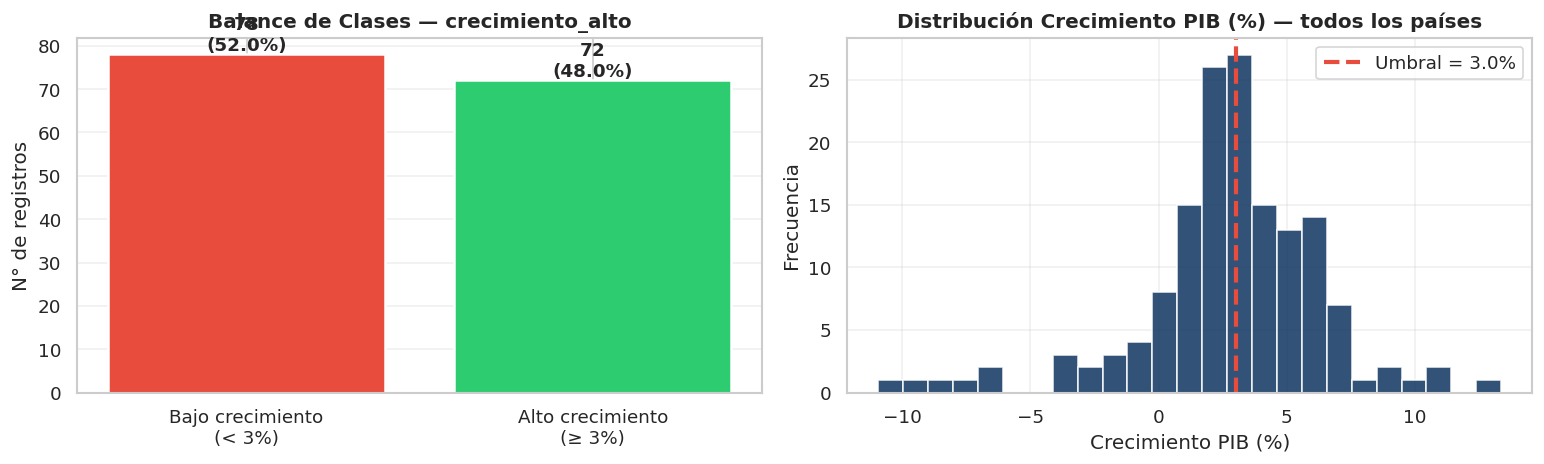

✅ Gráfica guardada: data/graficas/ml_balance_clases.png


In [6]:
# ── CELDA 3: Variable objetivo y features ─────────────────────────────────────

UMBRAL_CRECIMIENTO = 3.0  # % — umbral para definir "crecimiento alto"

# Limpiar filas con valores nulos en las columnas clave
FEATURES = ['pib_per_capita_usd', 'inflacion_pct', 'desempleo_pct',
            'exportaciones_pct_pib', 'importaciones_pct_pib']
TARGET   = 'crecimiento_alto'

df_ml = df.dropna(subset=['crecimiento_pib_pct'] + FEATURES).copy()

# Crear variable objetivo binaria
df_ml[TARGET] = (df_ml['crecimiento_pib_pct'] >= UMBRAL_CRECIMIENTO).astype(int)

# Mostrar balance de clases
conteo = df_ml[TARGET].value_counts()
total  = len(df_ml)

print('=' * 55)
print(f'{"VARIABLE OBJETIVO: crecimiento_alto":^55}')
print('=' * 55)
print(f'  Umbral: crecimiento_pib_pct >= {UMBRAL_CRECIMIENTO}%')
print(f'  Total registros usables: {total}')
print()
print(f'  Clase 0 (Bajo crecimiento < 3%):  {conteo.get(0,0):>3} registros  ({conteo.get(0,0)/total*100:.1f}%)')
print(f'  Clase 1 (Alto crecimiento >= 3%): {conteo.get(1,0):>3} registros  ({conteo.get(1,0)/total*100:.1f}%)')
print()

# Preparar X e y
X = df_ml[FEATURES].values
y = df_ml[TARGET].values

print(f'  X shape: {X.shape}  (features: {FEATURES})')
print(f'  y shape: {y.shape}')

# Visualizar balance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: Balance de clases
colores = ['#e74c3c', '#2ecc71']
etiquetas = ['Bajo crecimiento\n(< 3%)', 'Alto crecimiento\n(≥ 3%)']
axes[0].bar(etiquetas, [conteo.get(0,0), conteo.get(1,0)], color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Balance de Clases — crecimiento_alto', fontweight='bold')
axes[0].set_ylabel('N° de registros')
for i, v in enumerate([conteo.get(0,0), conteo.get(1,0)]):
    axes[0].text(i, v + 1, f'{v}\n({v/total*100:.1f}%)', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución del crecimiento PIB
axes[1].hist(df_ml['crecimiento_pib_pct'], bins=25, color='#0f3460', edgecolor='white', alpha=0.85)
axes[1].axvline(x=UMBRAL_CRECIMIENTO, color='#e74c3c', linewidth=2.5, linestyle='--',
                label=f'Umbral = {UMBRAL_CRECIMIENTO}%')
axes[1].set_title('Distribución Crecimiento PIB (%) — todos los países', fontweight='bold')
axes[1].set_xlabel('Crecimiento PIB (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../data/graficas', exist_ok=True)
plt.savefig('../data/graficas/ml_balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: data/graficas/ml_balance_clases.png')

## IV. Modelo 1 — Árbol de Decisión CART

### ¿Qué hace?
El árbol aprende una serie de preguntas sobre los indicadores económicos (PIB per cápita, inflación, desempleo, exportaciones, importaciones) para decidir si un año fue de **alto o bajo crecimiento económico**.

### Ventajas para este proyecto
- **No requiere escalado** de variables (a diferencia de la regresión logística)
- **Interpretable**: se puede visualizar el árbol completo con `plot_tree`
- **Captura relaciones no lineales** entre variables económicas
- Produce **importancia de variables** vía reducción de impureza Gini

### Estrategia: 3 splits para demostrar robustez
Se entrena y evalúa el mismo modelo con tres particiones distintas (80/20, 70/30, 60/40).

In [7]:
# ── CELDA 4: Función evaluar_split para Árbol de Decisión ─────────────────────
def evaluar_arbol(X, y, test_size, nombre_split, features):
    """
    Entrena y evalúa un DecisionTreeClassifier para un split dado.
    Retorna diccionario con métricas y el modelo entrenado.
    """
    # 1. Dividir datos (stratify conserva la proporción de clases)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # 2. Entrenar árbol con class_weight='balanced' para manejar desbalance
    modelo = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    )
    modelo.fit(X_train, y_train)

    # 3. Predecir
    y_pred      = modelo.predict(X_test)
    y_pred_prob = modelo.predict_proba(X_test)[:, 1]

    # 4. Métricas
    metricas = {
        'nombre'    : nombre_split,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_pred_prob),
        'modelo'    : modelo,
        'X_test'    : X_test,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'y_pred_prob': y_pred_prob,
    }

    # 5. Imprimir resumen del split
    print(f'\n{'─'*50}')
    print(f'  {nombre_split}  |  Train: {len(X_train)}  |  Test: {len(X_test)}')
    print(f'{'─'*50}')
    print(f'  Accuracy : {metricas["accuracy"]:.4f}')
    print(f'  Precision: {metricas["precision"]:.4f}')
    print(f'  Recall   : {metricas["recall"]:.4f}')
    print(f'  F1-Score : {metricas["f1"]:.4f}')
    print(f'  ROC-AUC  : {metricas["roc_auc"]:.4f}')

    return metricas

print('✅ Función evaluar_arbol() definida correctamente')

✅ Función evaluar_arbol() definida correctamente


In [8]:
# ── CELDA 5: Ejecutar los 3 splits — Árbol de Decisión ────────────────────────
print('=' * 50)
print(f'{"ÁRBOL DE DECISIÓN — 3 SPLITS":^50}')
print('=' * 50)

resultados_arbol = [
    evaluar_arbol(X, y, test_size=0.20, nombre_split='Split 80/20', features=FEATURES),
    evaluar_arbol(X, y, test_size=0.30, nombre_split='Split 70/30', features=FEATURES),
    evaluar_arbol(X, y, test_size=0.40, nombre_split='Split 60/40', features=FEATURES),
]

print('\n✅ Los 3 splits del Árbol de Decisión completados')

           ÁRBOL DE DECISIÓN — 3 SPLITS           

──────────────────────────────────────────────────
  Split 80/20  |  Train: 120  |  Test: 30
──────────────────────────────────────────────────
  Accuracy : 0.5333
  Precision: 0.5000
  Recall   : 0.5000
  F1-Score : 0.5000
  ROC-AUC  : 0.5312

──────────────────────────────────────────────────
  Split 70/30  |  Train: 105  |  Test: 45
──────────────────────────────────────────────────
  Accuracy : 0.6444
  Precision: 0.6364
  Recall   : 0.6364
  F1-Score : 0.6364
  ROC-AUC  : 0.6443

──────────────────────────────────────────────────
  Split 60/40  |  Train: 90  |  Test: 60
──────────────────────────────────────────────────
  Accuracy : 0.5333
  Precision: 0.5161
  Recall   : 0.5517
  F1-Score : 0.5333
  ROC-AUC  : 0.5339

✅ Los 3 splits del Árbol de Decisión completados


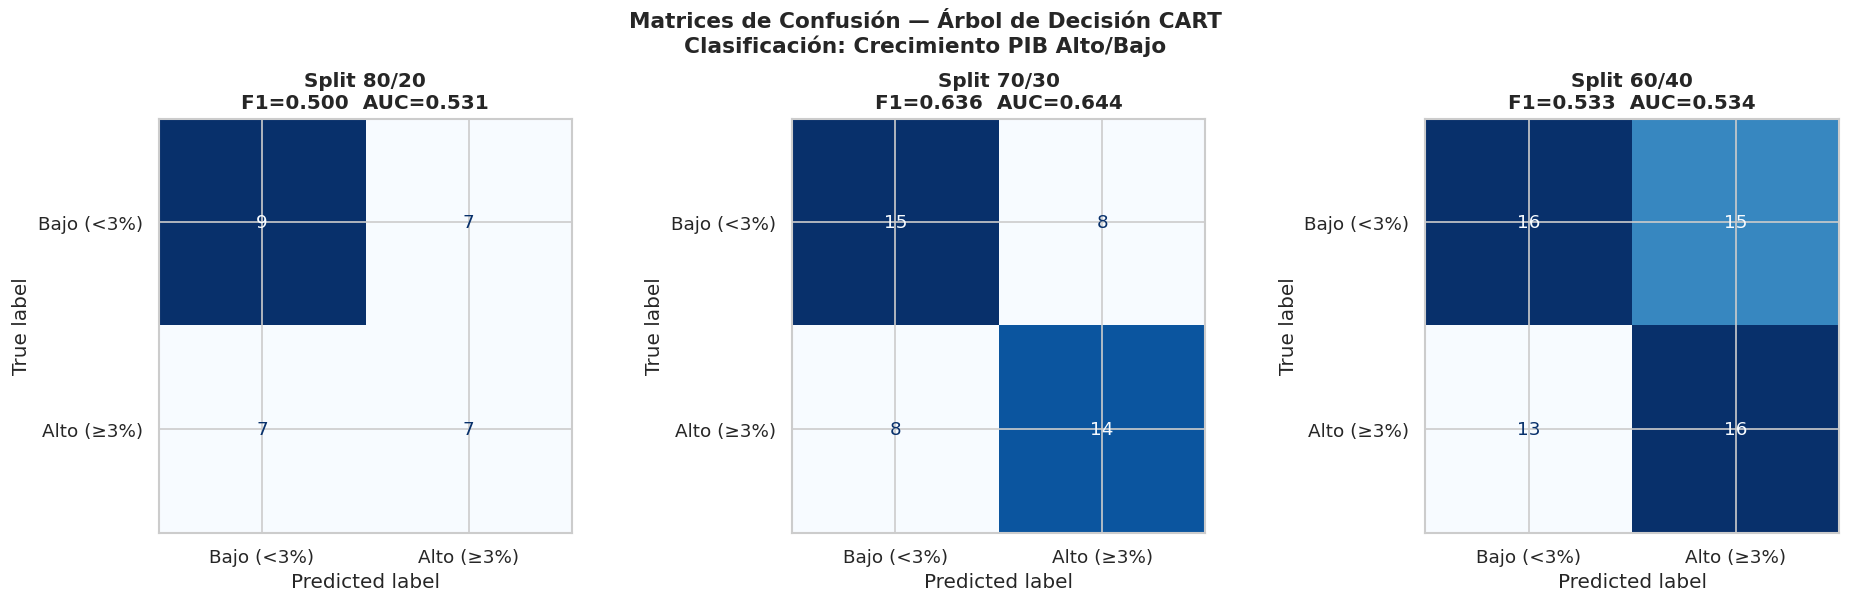

✅ Gráfica guardada: data/graficas/arbol_confusion_matrices.png


In [9]:
# ── CELDA 6: Matrices de Confusión — Árbol de Decisión ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Matrices de Confusión — Árbol de Decisión CART\nClasificación: Crecimiento PIB Alto/Bajo',
             fontsize=13, fontweight='bold')

for ax, res in zip(axes, resultados_arbol):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Bajo (<3%)', 'Alto (≥3%)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{res['nombre']}\nF1={res['f1']:.3f}  AUC={res['roc_auc']:.3f}",
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../data/graficas/arbol_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: data/graficas/arbol_confusion_matrices.png')

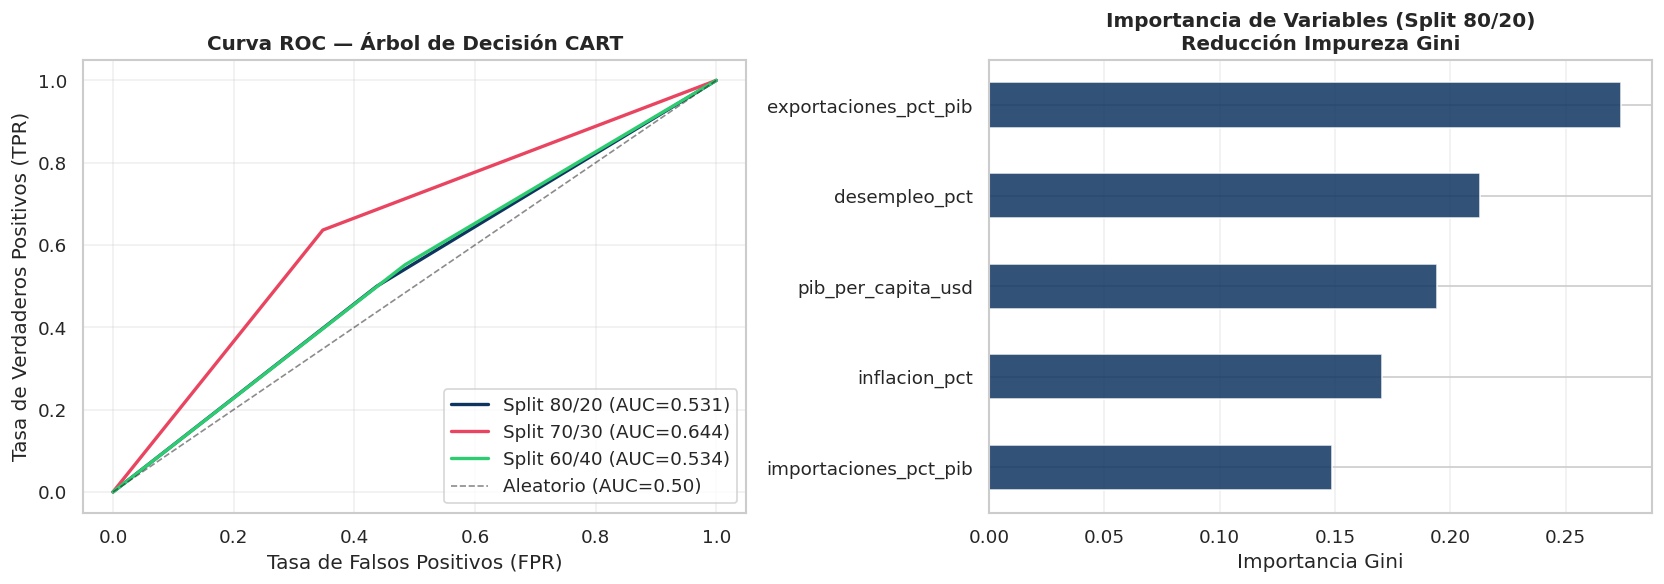

✅ Gráfica guardada: data/graficas/arbol_roc_importancia.png


In [10]:
# ── CELDA 7: Curvas ROC — Árbol de Decisión ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas ROC de los 3 splits
colores = ['#0f3460', '#e94560', '#2ecc71']
for res, color in zip(resultados_arbol, colores):
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_pred_prob'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{res['nombre']} (AUC={res['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Aleatorio (AUC=0.50)')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC — Árbol de Decisión CART', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Importancia de variables (Split 80/20)
modelo_s1 = resultados_arbol[0]['modelo']
importancias = pd.Series(modelo_s1.feature_importances_, index=FEATURES).sort_values()
importancias.plot(kind='barh', ax=axes[1], color='#0f3460', alpha=0.85)
axes[1].set_title('Importancia de Variables (Split 80/20)\nReducción Impureza Gini', fontweight='bold')
axes[1].set_xlabel('Importancia Gini')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../data/graficas/arbol_roc_importancia.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: data/graficas/arbol_roc_importancia.png')

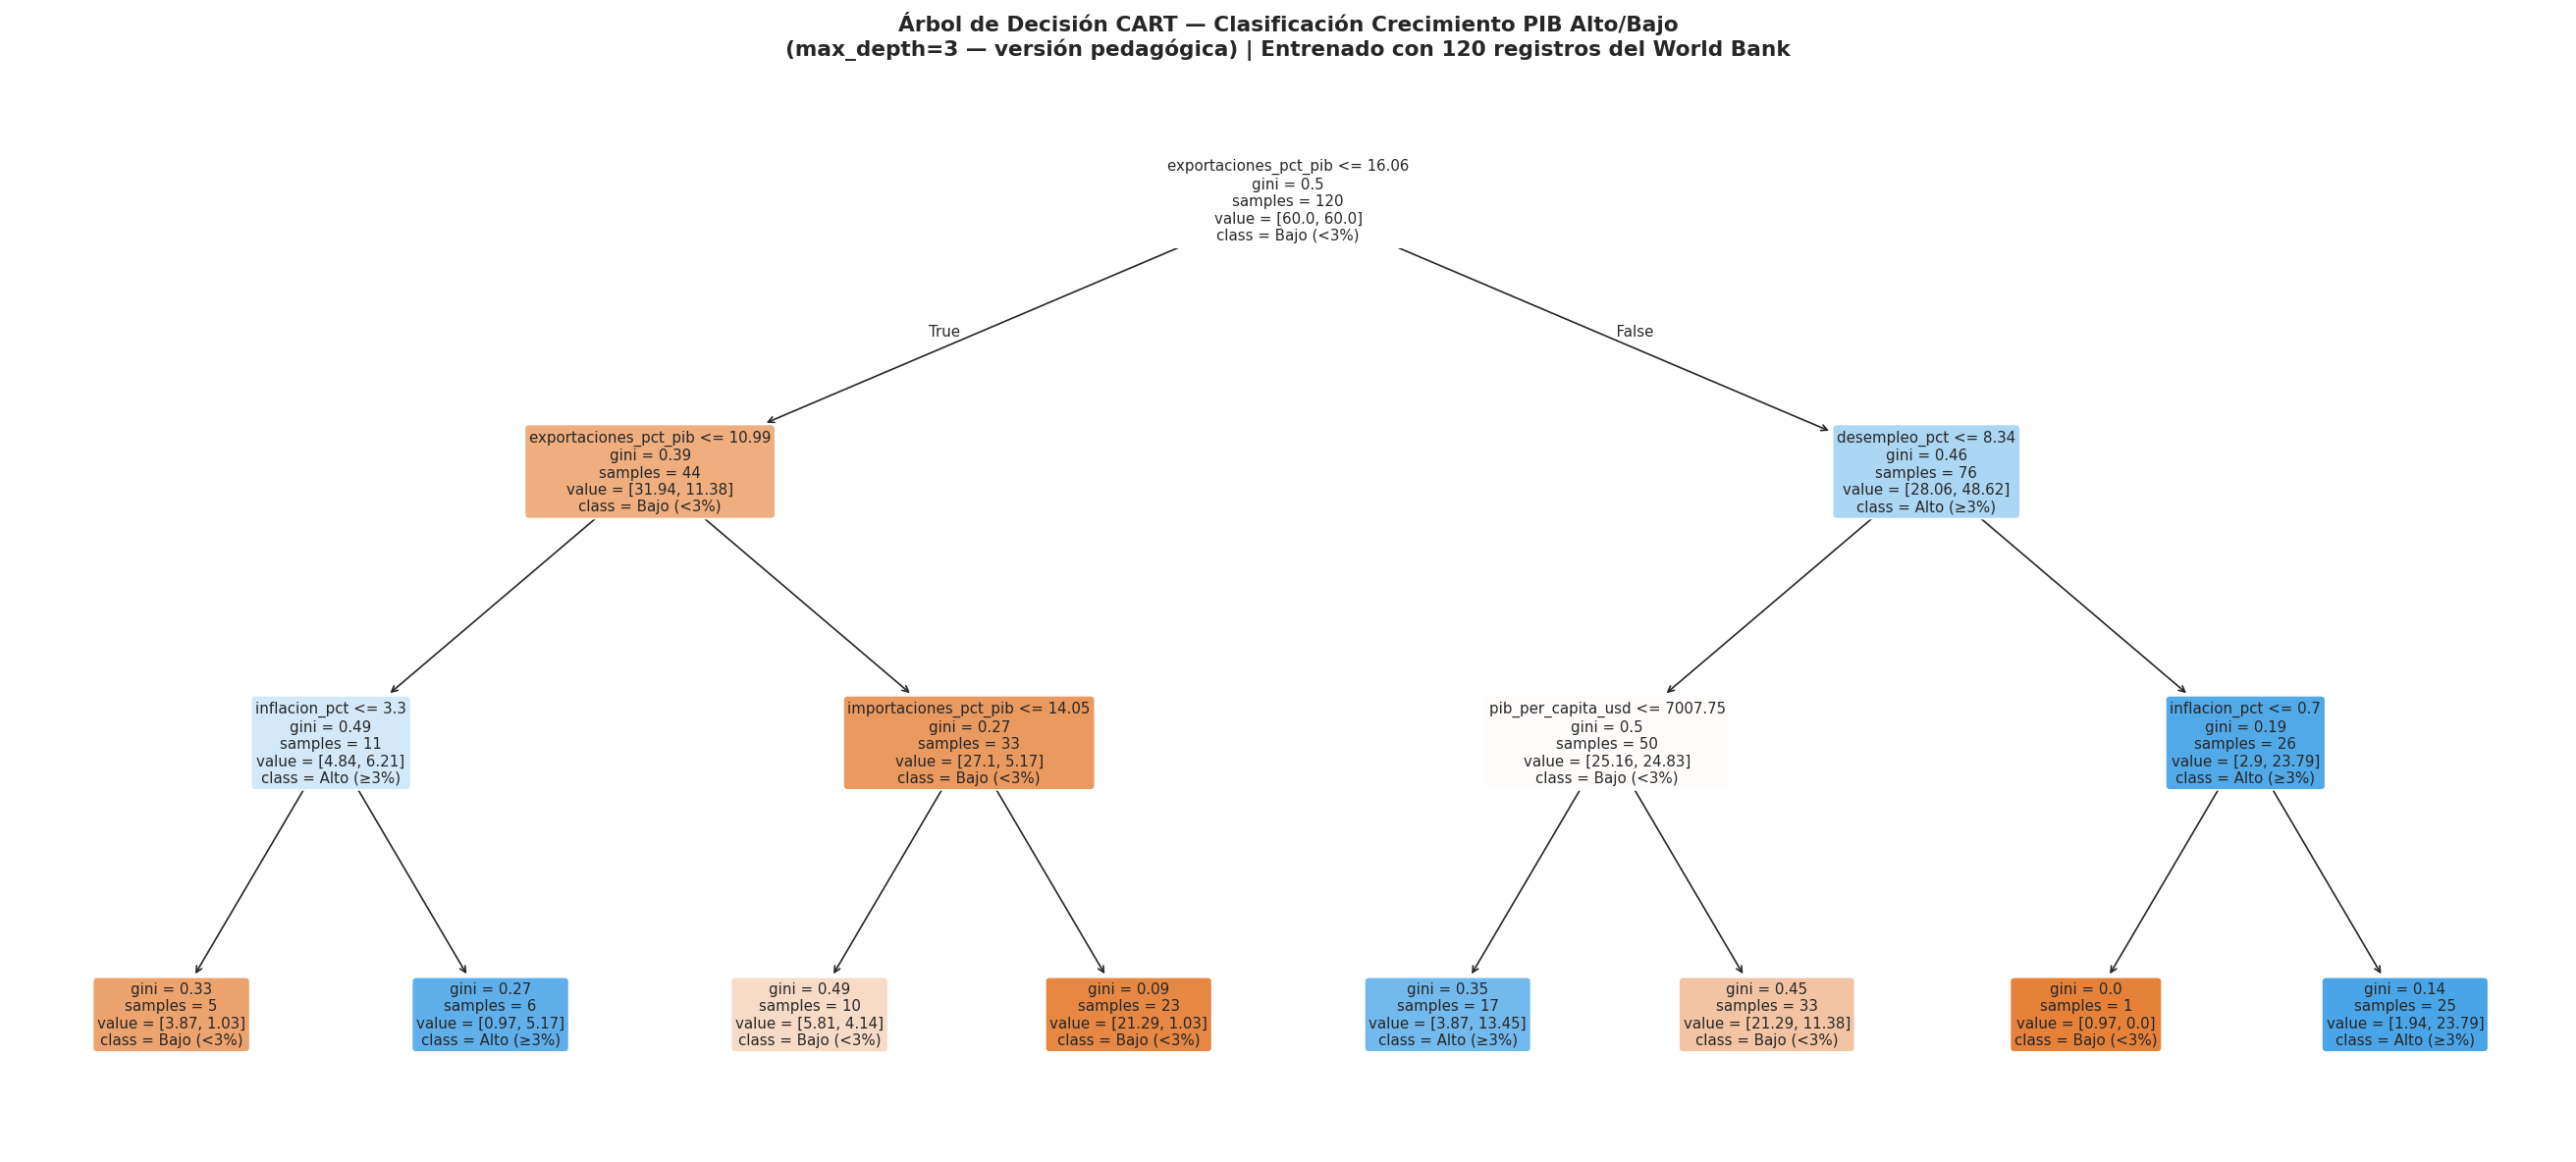


📋 Reglas del Árbol Pedagógico (max_depth=3):
|--- exportaciones_pct_pib <= 16.06
|   |--- exportaciones_pct_pib <= 10.99
|   |   |--- inflacion_pct <= 3.30
|   |   |   |--- class: 0
|   |   |--- inflacion_pct >  3.30
|   |   |   |--- class: 1
|   |--- exportaciones_pct_pib >  10.99
|   |   |--- importaciones_pct_pib <= 14.05
|   |   |   |--- class: 0
|   |   |--- importaciones_pct_pib >  14.05
|   |   |   |--- class: 0
|--- exportaciones_pct_pib >  16.06
|   |--- desempleo_pct <= 8.34
|   |   |--- pib_per_capita_usd <= 7007.75
|   |   |   |--- class: 1
|   |   |--- pib_per_capita_usd >  7007.75
|   |   |   |--- class: 0
|   |--- desempleo_pct >  8.34
|   |   |--- inflacion_pct <= 0.70
|   |   |   |--- class: 0
|   |   |--- inflacion_pct >  0.70
|   |   |   |--- class: 1

✅ Árbol pedagógico guardado: data/graficas/arbol_pedagogico_worldbank.png


In [11]:
# ── CELDA 8: Visualización del Árbol Pedagógico (max_depth=3) ─────────────────
# Reentrenamos con profundidad limitada para visualización clara
X_train_viz, _, y_train_viz, _ = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

modelo_viz = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
modelo_viz.fit(X_train_viz, y_train_viz)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_viz,
    feature_names=FEATURES,
    class_names=['Bajo (<3%)', 'Alto (≥3%)'],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2,
    fontsize=9,
    ax=ax
)
ax.set_title(
    'Árbol de Decisión CART — Clasificación Crecimiento PIB Alto/Bajo\n'
    f'(max_depth=3 — versión pedagógica) | Entrenado con {len(X_train_viz)} registros del World Bank',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/graficas/arbol_pedagogico_worldbank.png', dpi=150, bbox_inches='tight')
plt.show()

# Reglas en texto
print('\n📋 Reglas del Árbol Pedagógico (max_depth=3):')
print(export_text(modelo_viz, feature_names=FEATURES))
print('✅ Árbol pedagógico guardado: data/graficas/arbol_pedagogico_worldbank.png')

           ÁRBOL DE DECISIÓN — TABLA FINAL DE MÉTRICAS           


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,120,30,0.5333,0.5000,0.5000,0.5000,0.5312
Split 70/30,105,45,0.6444,0.6364,0.6364,0.6364,0.6443
Split 60/40,90,60,0.5333,0.5161,0.5517,0.5333,0.5339


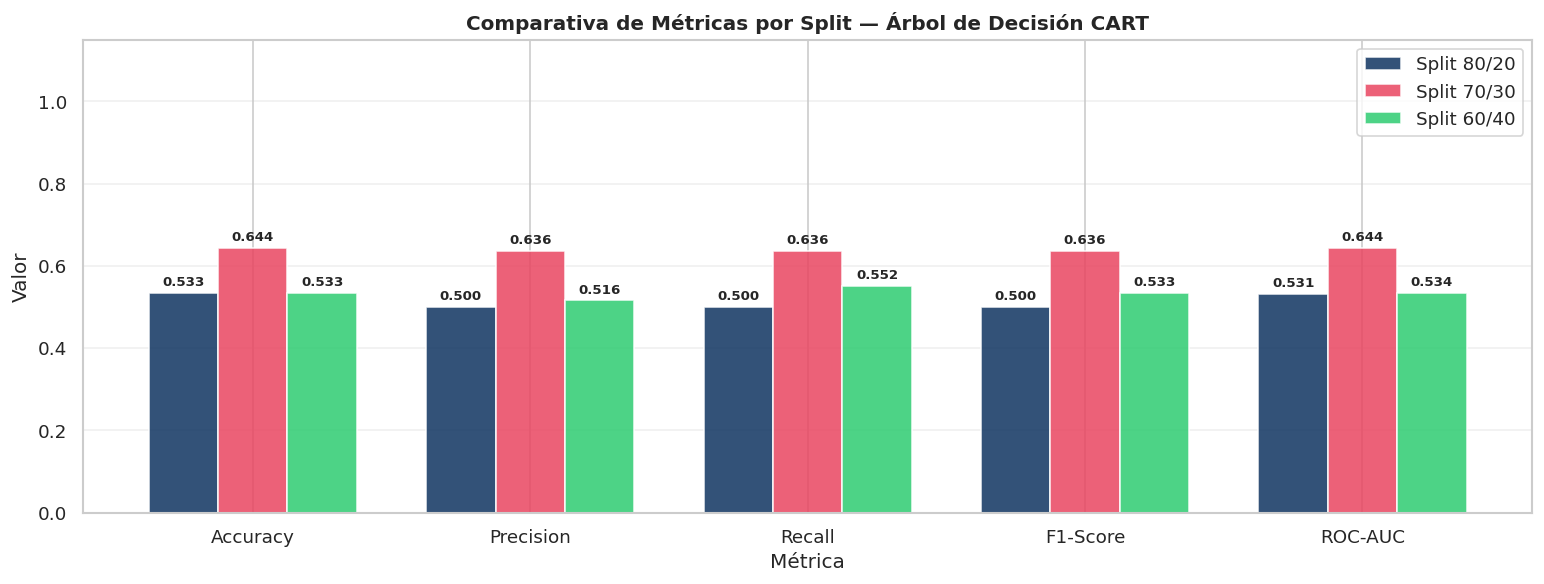

✅ Gráfica guardada: data/graficas/arbol_comparativa_metricas.png


In [12]:
# ── CELDA 9: Tabla Final de Métricas — Árbol de Decisión ─────────────────────
resumen_arbol = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados_arbol])

resumen_arbol.set_index('Split', inplace=True)

print('=' * 65)
print(f'{"ÁRBOL DE DECISIÓN — TABLA FINAL DE MÉTRICAS":^65}')
print('=' * 65)
display(resumen_arbol.style
    .background_gradient(cmap='Greens',
                         subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption('Árbol de Decisión CART — Clasificación Crecimiento PIB Mundial')
)

# Gráfico comparativo de métricas
metricas_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metricas_cols))
width = 0.25
colores = ['#0f3460', '#e94560', '#2ecc71']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (res, color) in enumerate(zip(resultados_arbol, colores)):
    vals = [round(res[k.lower().replace('-','').replace(' ','')], 4)
            if k.lower().replace('-','').replace(' ','') in res
            else resumen_arbol.loc[res['nombre'], k]
            for k in metricas_cols]
    vals = resumen_arbol.loc[res['nombre'], metricas_cols].values
    bars = ax.bar(x + i*width, vals, width, label=res['nombre'], color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_title('Comparativa de Métricas por Split — Árbol de Decisión CART', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metricas_cols)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../data/graficas/arbol_comparativa_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: data/graficas/arbol_comparativa_metricas.png')

## V. Modelo 2 — Regresión Logística Binaria

### ¿Qué hace?
La regresión logística estima la **probabilidad** de que un país experimente alto crecimiento económico (≥ 3%), usando los mismos indicadores económicos. A diferencia del árbol, dibuja una **frontera de decisión lineal** en el espacio de variables.

### Diferencias con el Árbol de Decisión
| Aspecto | Árbol CART | Regresión Logística |
|---|---|---|
| **Escalado** | No requerido | ✅ Sí (StandardScaler) |
| **Frontera** | Rectángulos | Línea/hiperplano recta |
| **Interpretación** | Importancia Gini | Coeficientes (log-odds) |
| **Probabilidad** | % de la hoja | Función sigmoide |

### Manejo del desbalance
Se usa `class_weight='balanced'` para que el modelo preste más atención a la clase minoritaria.

In [13]:
# ── CELDA 10: Función evaluar_split para Regresión Logística ──────────────────
def evaluar_logistica(X, y, test_size, nombre_split, features):
    """
    Entrena y evalúa un LogisticRegression para un split dado.
    Incluye StandardScaler (obligatorio para regresión logística).
    """
    # 1. Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # 2. Escalar variables (OBLIGATORIO para regresión logística)
    scaler  = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # 3. Entrenar modelo
    modelo = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    modelo.fit(X_train_sc, y_train)

    # 4. Predecir
    y_pred       = modelo.predict(X_test_sc)
    y_pred_prob  = modelo.predict_proba(X_test_sc)[:, 1]

    # 5. Métricas
    metricas = {
        'nombre'     : nombre_split,
        'train_size' : len(X_train),
        'test_size'  : len(X_test),
        'accuracy'   : accuracy_score(y_test, y_pred),
        'precision'  : precision_score(y_test, y_pred, zero_division=0),
        'recall'     : recall_score(y_test, y_pred, zero_division=0),
        'f1'         : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'    : roc_auc_score(y_test, y_pred_prob),
        'modelo'     : modelo,
        'scaler'     : scaler,
        'X_test_sc'  : X_test_sc,
        'y_test'     : y_test,
        'y_pred'     : y_pred,
        'y_pred_prob': y_pred_prob,
        'coefs'      : pd.Series(modelo.coef_[0], index=features)
    }

    print(f'\n{"─"*50}')
    print(f'  {nombre_split}  |  Train: {len(X_train)}  |  Test: {len(X_test)}')
    print(f'{"─"*50}')
    print(f'  Accuracy : {metricas["accuracy"]:.4f}')
    print(f'  Precision: {metricas["precision"]:.4f}')
    print(f'  Recall   : {metricas["recall"]:.4f}')
    print(f'  F1-Score : {metricas["f1"]:.4f}')
    print(f'  ROC-AUC  : {metricas["roc_auc"]:.4f}')

    return metricas

print('✅ Función evaluar_logistica() definida correctamente')

✅ Función evaluar_logistica() definida correctamente


In [14]:
# ── CELDA 11: Ejecutar los 3 splits — Regresión Logística ─────────────────────
print('=' * 50)
print(f'{"REGRESIÓN LOGÍSTICA — 3 SPLITS":^50}')
print('=' * 50)

resultados_log = [
    evaluar_logistica(X, y, test_size=0.20, nombre_split='Split 80/20', features=FEATURES),
    evaluar_logistica(X, y, test_size=0.30, nombre_split='Split 70/30', features=FEATURES),
    evaluar_logistica(X, y, test_size=0.40, nombre_split='Split 60/40', features=FEATURES),
]

print('\n✅ Los 3 splits de Regresión Logística completados')

          REGRESIÓN LOGÍSTICA — 3 SPLITS          

──────────────────────────────────────────────────
  Split 80/20  |  Train: 120  |  Test: 30
──────────────────────────────────────────────────
  Accuracy : 0.5333
  Precision: 0.5000
  Recall   : 0.5000
  F1-Score : 0.5000
  ROC-AUC  : 0.6652

──────────────────────────────────────────────────
  Split 70/30  |  Train: 105  |  Test: 45
──────────────────────────────────────────────────
  Accuracy : 0.5556
  Precision: 0.5385
  Recall   : 0.6364
  F1-Score : 0.5833
  ROC-AUC  : 0.5751

──────────────────────────────────────────────────
  Split 60/40  |  Train: 90  |  Test: 60
──────────────────────────────────────────────────
  Accuracy : 0.5000
  Precision: 0.4857
  Recall   : 0.5862
  F1-Score : 0.5312
  ROC-AUC  : 0.5250

✅ Los 3 splits de Regresión Logística completados


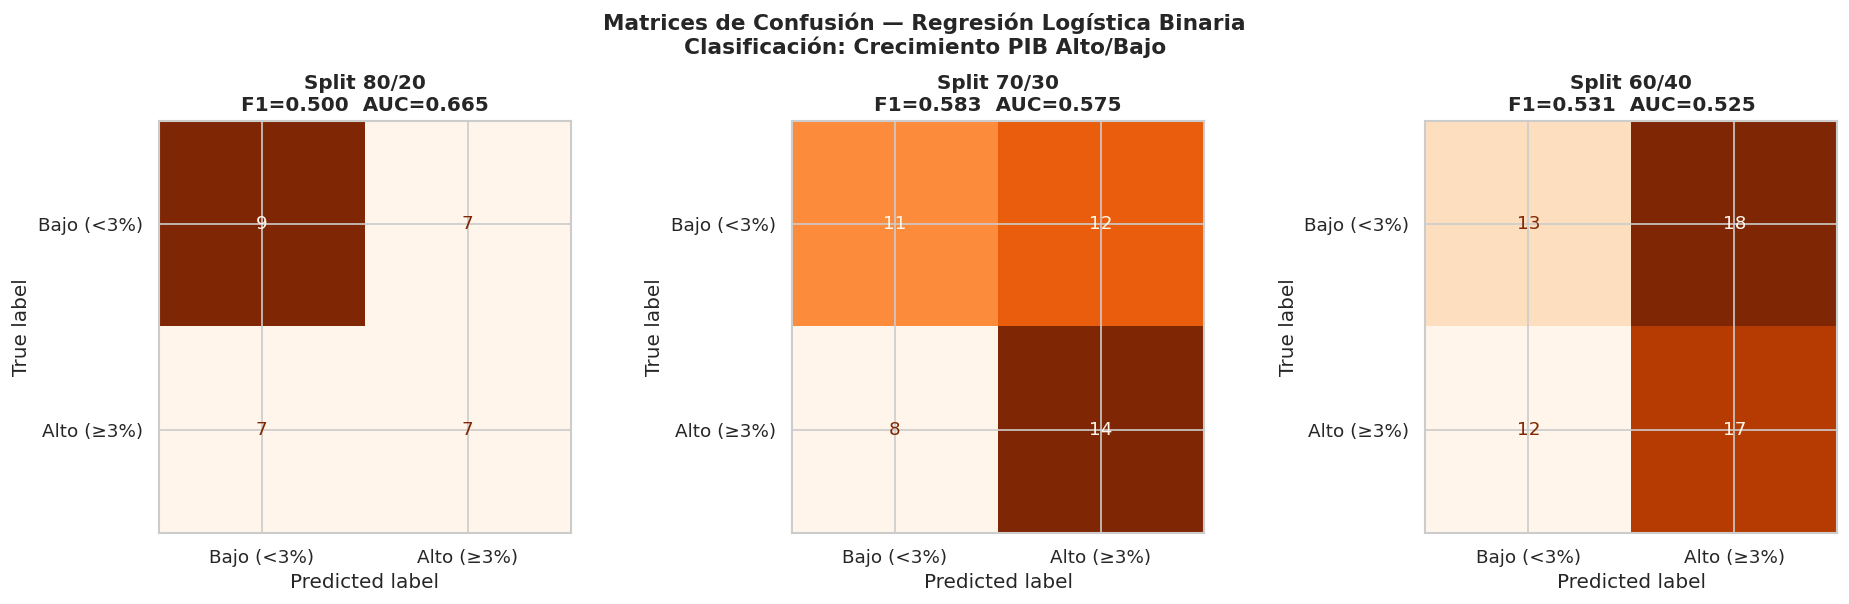

✅ Gráfica guardada: data/graficas/logistica_confusion_matrices.png


In [15]:
# ── CELDA 12: Matrices de Confusión + Curvas ROC — Regresión Logística ────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Matrices de Confusión — Regresión Logística Binaria\nClasificación: Crecimiento PIB Alto/Bajo',
             fontsize=13, fontweight='bold')

for ax, res in zip(axes, resultados_log):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Bajo (<3%)', 'Alto (≥3%)'])
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f"{res['nombre']}\nF1={res['f1']:.3f}  AUC={res['roc_auc']:.3f}",
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../data/graficas/logistica_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: data/graficas/logistica_confusion_matrices.png')

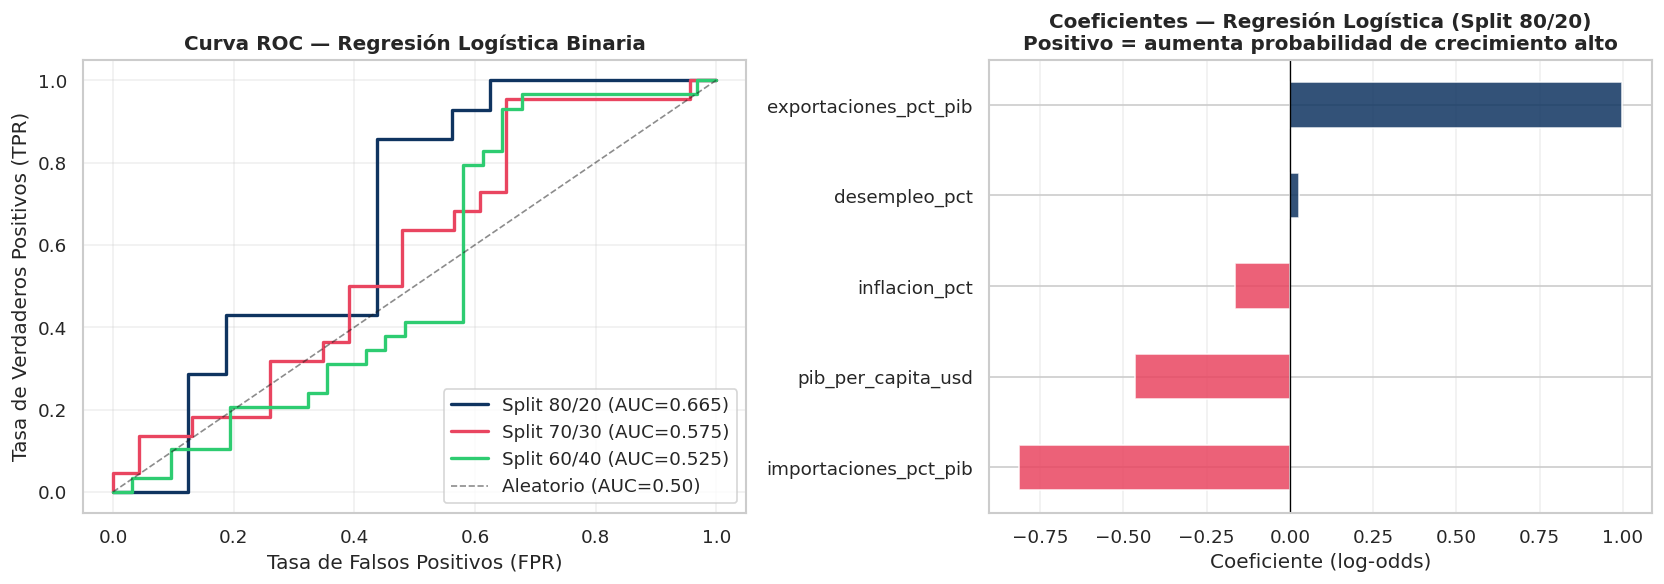

✅ Gráfica guardada: data/graficas/logistica_roc_coeficientes.png


In [16]:
# ── CELDA 13: Curvas ROC + Coeficientes — Regresión Logística ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas ROC
colores = ['#0f3460', '#e94560', '#2ecc71']
for res, color in zip(resultados_log, colores):
    fpr, tpr, _ = roc_curve(res['y_test'], res['y_pred_prob'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{res['nombre']} (AUC={res['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Aleatorio (AUC=0.50)')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC — Regresión Logística Binaria', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Coeficientes (Split 80/20)
coefs = resultados_log[0]['coefs'].sort_values()
colores_coef = ['#e94560' if c < 0 else '#0f3460' for c in coefs]
coefs.plot(kind='barh', ax=axes[1], color=colores_coef, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Coeficientes — Regresión Logística (Split 80/20)\n'
                  'Positivo = aumenta probabilidad de crecimiento alto', fontweight='bold')
axes[1].set_xlabel('Coeficiente (log-odds)')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../data/graficas/logistica_roc_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: data/graficas/logistica_roc_coeficientes.png')

In [17]:
# ── CELDA 14: Tabla Final de Métricas — Regresión Logística ───────────────────
resumen_log = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados_log])

resumen_log.set_index('Split', inplace=True)

print('=' * 65)
print(f'{"REGRESIÓN LOGÍSTICA — TABLA FINAL DE MÉTRICAS":^65}')
print('=' * 65)
display(resumen_log.style
    .background_gradient(cmap='Oranges',
                         subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption('Regresión Logística Binaria — Clasificación Crecimiento PIB Mundial')
)

          REGRESIÓN LOGÍSTICA — TABLA FINAL DE MÉTRICAS          


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,120,30,0.5333,0.5000,0.5000,0.5000,0.6652
Split 70/30,105,45,0.5556,0.5385,0.6364,0.5833,0.5751
Split 60/40,90,60,0.5000,0.4857,0.5862,0.5312,0.5250


## VI. Comparación Final — Árbol de Decisión vs Regresión Logística

         COMPARACIÓN FINAL — PROMEDIO 3 SPLITS         


,Árbol CART,Reg. Logística
Accuracy,0.5703,0.5296
Precision,0.5508,0.5081
Recall,0.5627,0.5742
F1-Score,0.5566,0.5382
ROC-AUC,0.5698,0.5884


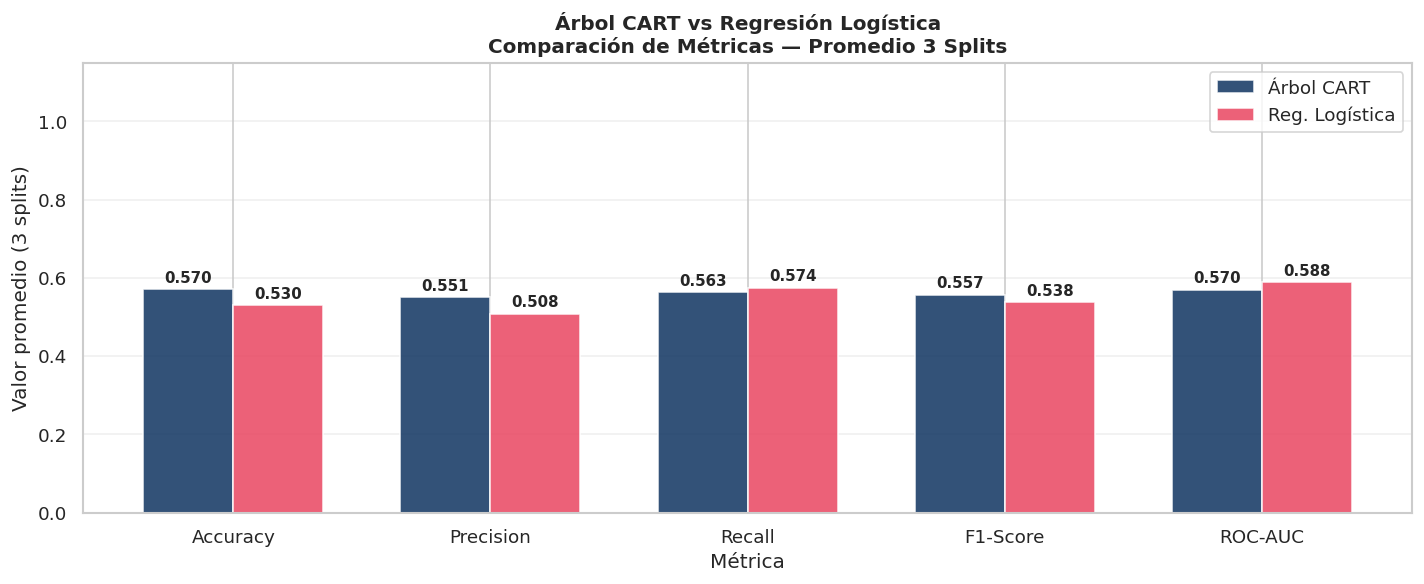

✅ Gráfica guardada: data/graficas/comparacion_modelos_worldbank.png


In [18]:
# ── CELDA 15: Comparación Final de Ambos Modelos ──────────────────────────────

# Promedios entre splits
prom_arbol = resumen_arbol[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].mean()
prom_log   = resumen_log[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].mean()

comparacion = pd.DataFrame({
    'Árbol CART': prom_arbol.round(4),
    'Reg. Logística': prom_log.round(4)
})

print('=' * 55)
print(f'{"COMPARACIÓN FINAL — PROMEDIO 3 SPLITS":^55}')
print('=' * 55)
display(comparacion.style
    .background_gradient(cmap='RdYlGn', axis=1)
    .format('{:.4f}')
    .set_caption('Árbol CART vs Regresión Logística — Promedio de 3 splits')
)

# Gráfico de radar / barras comparativo
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metricas_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, comparacion['Árbol CART'], width,
               label='Árbol CART', color='#0f3460', alpha=0.85)
bars2 = ax.bar(x + width/2, comparacion['Reg. Logística'], width,
               label='Reg. Logística', color='#e94560', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor promedio (3 splits)')
ax.set_title('Árbol CART vs Regresión Logística\nComparación de Métricas — Promedio 3 Splits', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../data/graficas/comparacion_modelos_worldbank.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: data/graficas/comparacion_modelos_worldbank.png')